In [26]:
# Import TensorFlow and check the installed version
import tensorflow as tf
print(tf.__version__)


2.20.0


In [27]:
# Import TensorFlow and load the MNIST handwritten digits dataset
# The dataset is split into training (60k images) and testing (10k images)
import tensorflow as tf
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Print raw pixel values of a single training image (28x28 array, values 0-255)
print(x_train[1])


[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  51 159 253 159  50   0   0   0   0
    0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0  48 238 252 252 252 237   0   0   0   0
    0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0  54 227 253 252 239 233 252  57   6   0   0
    0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  10  60 224 252 253 252 202  84 252 253 122   0   0
    0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 163 252 252 252 25

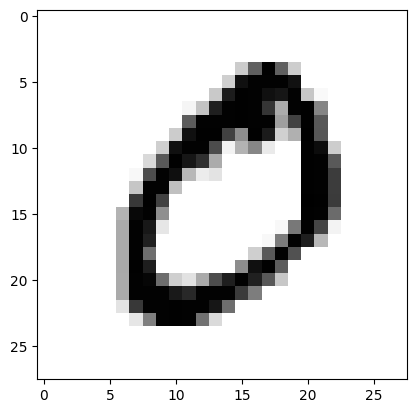

In [28]:
# Visualize a training image as a grayscale plot
import matplotlib.pyplot as plt
plt.imshow(x_train[1], cmap=plt.cm.binary)
plt.show()


In [29]:
# Print the raw pixel array with wider line width for readability
import numpy as np
np.set_printoptions(linewidth=120)
print(x_train[1])


[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  51 159 253 159  50   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0  48 238 252 252 252 237   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0  54 227 253 252 239 233 252  57   6   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  10  60 224 252 253 252 202  84 252 253 122   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 163 252 252 252 253 252 252  96 18

In [30]:
# Normalize pixel values from 0-255 to 0-1 range
# This helps the neural network train faster and more effectively
x_train = x_train / 255
x_test = x_test / 255

# Print a normalized image to verify values are between 0 and 1
np.set_printoptions(linewidth=100)
print(x_train[10])


[[0.         0.         0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.  

In [31]:
# Apply L2 normalization to the data (scales each sample to unit norm)
x_train = tf.keras.utils.normalize(x_train)
x_test = tf.keras.utils.normalize(x_test)


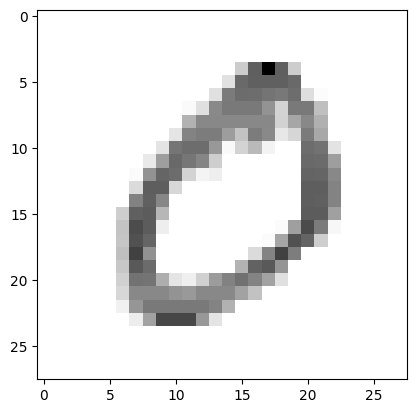

In [32]:
# Visualize a training image after normalization
# The image may look slightly different due to scaling
plt.imshow(x_train[1], cmap=plt.cm.binary)
plt.show()


In [33]:
# Build a simple feedforward neural network
model = tf.keras.models.Sequential()

# Flatten layer: converts 28x28 image into a 784-element 1D vector
model.add(tf.keras.layers.Flatten())

# First hidden layer: 128 neurons with ReLU activation
model.add(tf.keras.layers.Dense(128, activation="relu"))

# Second hidden layer: 62 neurons with ReLU activation
model.add(tf.keras.layers.Dense(62, activation="relu"))

# Output layer: 10 neurons (one per digit 0-9) with softmax for probabilities
model.add(tf.keras.layers.Dense(10, activation="softmax"))


In [43]:
# Build the model with explicit input shape and display its summary
model.build(input_shape=(32, 28, 28))  # batch_size=32, height=28, width=28
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)                  │ (32, 784)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (32, 128)                   │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (32, 62)                    │           7,998 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (32, 10)                    │             630 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 327,326 (1.25 MB)

 Trainable params: 109,108 (426.20 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 218,218 (852.42 KB)

In [35]:
# Compile the model with Adam optimizer and sparse categorical crossentropy loss
# Sparse crossentropy is used because labels are integers (0-9), not one-hot encoded
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=['accuracy'])

# Train the model for 4 epochs on the training data
model.fit(x_train, y_train, epochs=4)


Epoch 1/4
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9198 - loss: 0.2749
Epoch 2/4
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9644 - loss: 0.1160
Epoch 3/4
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9746 - loss: 0.0814
Epoch 4/4
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9811 - loss: 0.0603


In [36]:
# Evaluate the model on the test dataset
# Returns loss and accuracy on unseen data
val_acc, val_loss = model.evaluate(x_test, y_test)
print(val_acc, val_loss)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9688 - loss: 0.0992
0.09915342926979065 0.9688000082969666


In [37]:
# Save the trained model to disk in Keras format
model.save("mnist.keras")


In [38]:
# Load the saved model from disk to verify it works
new_model = tf.keras.models.load_model("mnist.keras")


In [39]:
# Run predictions on the entire test set using the loaded model
predictions = new_model.predict([x_test])


 64/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

C:\Users\devs4\AppData\Roaming\Python\Python313\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=('Tensor(shape=(32, 28, 28))',)
  warnings.warn(msg)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


C:\Users\devs4\AppData\Roaming\Python\Python313\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=('Tensor(shape=(None, 28, 28))',)
  warnings.warn(msg)


In [40]:
# Print the predicted digit for the first test image
# argmax returns the index with the highest probability (the predicted digit)
import numpy as np
print(np.argmax(predictions[0]))


7


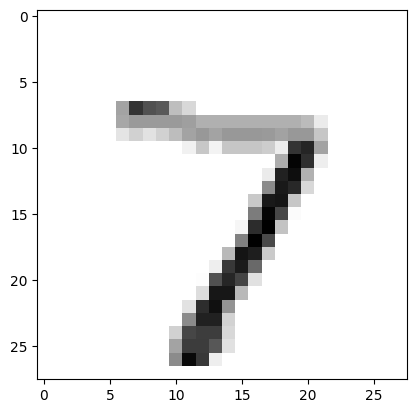

In [41]:
# Visualize the first test image to verify the prediction
plt.imshow(x_test[0], cmap=plt.cm.binary)
plt.show()
